In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd

from astropy.io import fits
from scipy.signal import detrend, find_peaks
from scipy.ndimage import gaussian_filter1d
from astropy.timeseries import LombScargle

In [2]:
#Data Upload
VVV_data = fits.open('VVV_Sample.fits')

Id_b278, Id_b279 = VVV_data[1].data, VVV_data[11].data
Ks_b278, Ks_b279 = VVV_data[2].data, VVV_data[12].data
Ks_err_b278, Ks_err_b279 = VVV_data[5].data, VVV_data[15].data
Ks_mjd_b278, Ks_mjd_b279 = VVV_data[8].data, VVV_data[18].data
VVV_data.info()

def remove_nans(array2d):
    return [row[~np.isnan(row)] for row in array2d]

Ks_b278 = remove_nans(Ks_b278)
Ks_b279 = remove_nans(Ks_b279)
Ks_err_b278 = remove_nans(Ks_err_b278)
Ks_err_b279 = remove_nans(Ks_err_b279)
Ks_mjd_b278 = remove_nans(Ks_mjd_b278)
Ks_mjd_b279 = remove_nans(Ks_mjd_b279)

Filename: VVV_Sample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  ID_B278       1 ImageHDU         7   (304,)   int64   
  2  KS_B278       1 ImageHDU         8   (523, 304)   float64   
  3  H_B278        1 ImageHDU         8   (32, 304)   float64   
  4  J_B278        1 ImageHDU         8   (25, 304)   float64   
  5  KS_ERR_B278    1 ImageHDU         8   (523, 304)   float64   
  6  H_ERR_B278    1 ImageHDU         8   (32, 304)   float64   
  7  J_ERR_B278    1 ImageHDU         8   (25, 304)   float64   
  8  KS_MJD_B278    1 ImageHDU         8   (523, 304)   float64   
  9  H_MJD_B278    1 ImageHDU         8   (32, 304)   float64   
 10  J_MJD_B278    1 ImageHDU         8   (25, 304)   float64   
 11  ID_B279       1 ImageHDU         7   (286,)   int64   
 12  KS_B279       1 ImageHDU         8   (960, 286)   float64   
 13  H_B279        1 ImageHDU         8   (14, 286)   float64   
 14  J_B279        1

In [3]:
def normalize(y):
    return (y - np.mean(y)) / np.std(y)

def compute_phase(t, period):
    return (t / period) % 1

In [4]:
def phase_entropy(t, y, period, bins=None):
    phase = compute_phase(t, period)
    if bins is None:
        bins = max(10, int(np.sqrt(len(y))))
    H, _, _ = np.histogram2d(phase,y,bins=bins)

    P = H / np.sum(H)
    P = P[P > 0]
    entropy = -np.sum(P * np.log(P))
    return entropy

In [5]:
def minimum_entropy_search(t, y, ls_period,search_width = 0.05,n_periods=3000):

    min_period = ls_period * (1 - search_width)
    max_period = ls_period * (1 + search_width)
    period_grid = np.linspace(min_period,max_period,n_periods)
    entropies = []
    for P in period_grid:
        S = phase_entropy(t, y, P)
        entropies.append(S)
    entropies = np.array(entropies)
    smooth_entropy = gaussian_filter1d(entropies, sigma=2)
    best_index = np.argmin(smooth_entropy)
    best_period = period_grid[best_index]
    min_entropy = smooth_entropy[best_index]
    return {"period_grid": period_grid,"entropies": entropies,"smooth_entropy": smooth_entropy,
        "best_period": best_period,"min_entropy": min_entropy}

In [6]:
def analyze_star(t, y, dy, star_id, min_f, max_f):

    if len(t) < 15:
        return None

    # Filtrado por errores
    mask = dy < np.percentile(dy, 90)

    t = t[mask]
    y = y[mask]
    dy = dy[mask]

    if len(t) < 15:
        return None

    # Normalización
    y = normalize(y)

    # Remover offset
    y = y - np.median(y)

    # Lomb-Scargle
    ls = LombScargle(t, y)

    frequency, power = ls.autopower(
        minimum_frequency=min_f,
        maximum_frequency=max_f,
        samples_per_peak=10
    )

    # Encontrar múltiples picos
    peaks, _ = find_peaks(power)

    if len(peaks) == 0:
        return None

    peak_powers = power[peaks]

    top_indices = np.argsort(peak_powers)[-5:]

    candidate_peaks = peaks[top_indices]

    candidate_periods = 1 / frequency[candidate_peaks]

    # Refinamiento por mínima entropía
    entropy_results = []

    for P0 in candidate_periods:

        me_result = minimum_entropy_search(
            t,
            y,
            P0
        )

        entropy_results.append(me_result)

    # Escoger mejor mínimo global
    best_entropy_result = min(
        entropy_results,
        key=lambda r: r["min_entropy"]
    )

    best_period = best_entropy_result["best_period"]

    fap = ls.false_alarm_probability(np.max(power))

    peak_ratio = np.max(power) / np.median(power)

    return {

        "id": star_id,

        "t": t,
        "y": y,
        "dy": dy,

        "frequency": frequency,
        "power": power,

        "ls_period": 1 / frequency[np.argmax(power)],

        "me_period": best_period,

        "fap": fap,
        "peak_ratio": peak_ratio,

        "entropy_grid": best_entropy_result["period_grid"],
        "entropies": best_entropy_result["entropies"],
        "smooth_entropy": best_entropy_result["smooth_entropy"],
        "min_entropy": best_entropy_result["min_entropy"]
    }

In [7]:
results = []
good_results = []

n_stars = len(Ks_b278)

min_f = 1 / 101
max_f = 1 / 0.1

for i in range(n_stars):

    t = Ks_mjd_b278[i]
    y = Ks_b278[i]
    dy = Ks_err_b278[i]
    star_id = Id_b278[i]

    result = analyze_star(
        t,
        y,
        dy,
        star_id,
        min_f,
        max_f
    )

    if result is not None:

        results.append(result)

        if (
            result["peak_ratio"] > 20 and
            result["fap"] < 0.001
        ):
            good_results.append(result)

In [8]:
print("Total estrellas:", len(results))
print("Buenas estrellas:", len(good_results))

for r in good_results[:10]:

    print(
        f"ID: {r['id']} | "
        f"LS = {r['ls_period']:.4f} d | "
        f"ME = {r['me_period']:.4f} d | "
        f"FAP = {r['fap']:.2e}"
    )

Total estrellas: 304
Buenas estrellas: 170
ID: 13648911009610 | LS = 1.9818 d | ME = 1.9819 d | FAP = 1.64e-38
ID: 13603846011060 | LS = 0.9968 d | ME = 0.9970 d | FAP = 1.47e-40
ID: 13669390010041 | LS = 0.6598 d | ME = 1.9945 d | FAP = 3.28e-34
ID: 13657095011090 | LS = 0.7513 d | ME = 2.9916 d | FAP = 5.03e-23
ID: 13612046006196 | LS = 0.1772 d | ME = 0.1772 d | FAP = 3.75e-57
ID: 13616133005463 | LS = 0.6939 d | ME = 0.6938 d | FAP = 1.36e-18
ID: 13632529013036 | LS = 0.4219 d | ME = 0.4219 d | FAP = 6.06e-58
ID: 13607953007645 | LS = 3.5371 d | ME = 3.5373 d | FAP = 1.49e-33
ID: 13632521004540 | LS = 0.4740 d | ME = 0.9480 d | FAP = 1.46e-39
ID: 13624335012969 | LS = 0.6496 d | ME = 0.6496 d | FAP = 1.89e-36


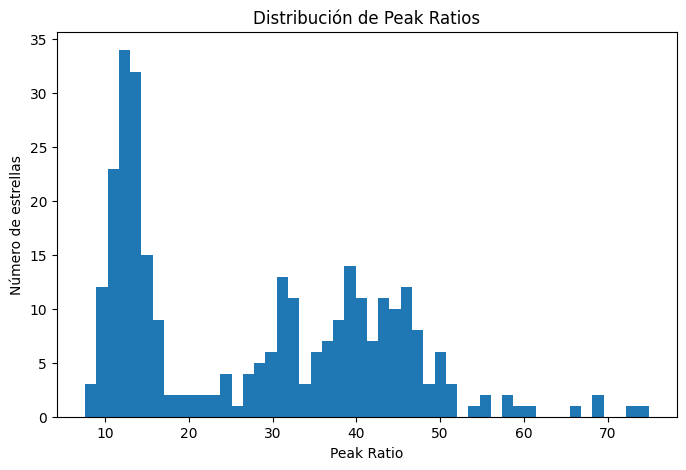

In [9]:
all_ratios = [r["peak_ratio"] for r in results]

plt.figure(figsize=(8,5))

plt.hist(all_ratios, bins=50)

plt.xlabel("Peak Ratio")
plt.ylabel("Número de estrellas")

plt.title("Distribución de Peak Ratios")

plt.show()

In [10]:
# ============================================================
# CELDA 11 — SELECCIÓN DE ESTRELLAS
# ============================================================

n_select_total = 50
n_entropy = 10

# ------------------------------------------------------------
# Trabajar sobre TODAS las estrellas
# ------------------------------------------------------------

df_results = pd.DataFrame([

    {
        "idx": i,
        "peak_ratio": r["peak_ratio"],
        "fap": r["fap"]
    }

    for i, r in enumerate(results)

])

if len(results) <= n_select_total:

    selected_stars = results

else:

    # ========================================================
    # 20 mejores → mínima entropía
    #
    # priorizamos:
    #   peak_ratio alto
    #   FAP bajo
    # ========================================================

    entropy_idx = (

        df_results

        .sort_values(
            ["peak_ratio", "fap"],
            ascending=[False, True]
        )

        .head(n_entropy)["idx"]

        .tolist()

    )

    entropy_stars = [

        results[i]

        for i in entropy_idx

    ]

    # ========================================================
    # 30 restantes → repartidas por peak ratio
    # ========================================================

    remaining_df = (

        df_results[
            ~df_results["idx"].isin(entropy_idx)
        ]

        .copy()

    )

    n_remaining = n_select_total - n_entropy

    remaining_df["bin"] = pd.qcut(

        remaining_df["peak_ratio"],

        q=min(10, len(remaining_df)),

        duplicates="drop"

    )

    sampled_idx = []

    groups = remaining_df.groupby("bin")

    per_bin = max(
        1,
        n_remaining // len(groups)
    )

    for _, group in groups:

        k = min(
            per_bin,
            len(group)
        )

        sampled_idx.extend(

            random.sample(
                group["idx"].tolist(),
                k
            )

        )

    # completar si faltan
    missing = n_remaining - len(sampled_idx)

    if missing > 0:

        available = list(

            set(
                remaining_df["idx"]
            )

            - set(sampled_idx)

        )

        sampled_idx.extend(

            random.sample(

                available,

                min(
                    missing,
                    len(available)
                )

            )

        )

    non_entropy_stars = [

        results[i]

        for i in sampled_idx[:n_remaining]

    ]

    selected_stars = (

        entropy_stars
        +
        non_entropy_stars

    )

# ------------------------------------------------------------
# Separación final
# ------------------------------------------------------------

entropy_stars = selected_stars[:min(
    n_entropy,
    len(selected_stars)
)]

non_entropy_stars = selected_stars[
    len(entropy_stars):
]

print(f"Total seleccionadas: {len(selected_stars)}")
print(f"Con mínima entropía: {len(entropy_stars)}")
print(f"Solo Lomb-Scargle: {len(non_entropy_stars)}")

Total seleccionadas: 50
Con mínima entropía: 10
Solo Lomb-Scargle: 40


In [11]:
def plot_star_summary(
    result,
    index=None,
    save_path=None,
    use_entropy=True
):

    t = result["t"]
    y = result["y"]

    frequency = result["frequency"]
    power = result["power"]

    ls_period = result["ls_period"]

    star_id = result["id"]

    # ========================================================
    # CON MÍNIMA ENTROPÍA
    # ========================================================

    if use_entropy:

        me_period = result["me_period"]

        entropy_grid = result["entropy_grid"]

        smooth_entropy = result["smooth_entropy"]

        delta_p = me_period - ls_period

        relative_delta = delta_p / ls_period

        fig, axs = plt.subplots(
            1,
            5,
            figsize=(26,4)
        )

    # ========================================================
    # SOLO LOMB-SCARGLE
    # ========================================================

    else:

        fig, axs = plt.subplots(
            1,
            3,
            figsize=(16,4)
        )

    # ========================================================
    # PANEL 1 — CURVA DE LUZ
    # ========================================================

    axs[0].scatter(
        t,
        y,
        s=10
    )

    axs[0].invert_yaxis()

    axs[0].set_xlabel("Tiempo (MJD)")

    axs[0].set_ylabel("Magnitud")

    axs[0].set_title(
        "Curva de luz observada"
    )

    # ========================================================
    # PANEL 2 — LOMB-SCARGLE
    # ========================================================

    axs[1].plot(
        frequency,
        power
    )

    axs[1].set_xlabel("Frecuencia")

    axs[1].set_ylabel("Potencia")

    axs[1].set_title(
        "Periodograma Lomb-Scargle\n"
        f"P_LS = {ls_period:.6f} d"
    )

    # ========================================================
    # CASO CON MÍNIMA ENTROPÍA
    # ========================================================

    if use_entropy:

        # ----------------------------------------------------
        # PANEL 3 — MÍNIMA ENTROPÍA
        # ----------------------------------------------------

        axs[2].plot(
            entropy_grid,
            smooth_entropy
        )

        axs[2].invert_yaxis()

        axs[2].set_xlabel("Periodo")

        axs[2].set_ylabel("Entropía")

        axs[2].set_title(
            "Refinamiento por mínima entropía\n"
            f"P_ME = {me_period:.6f} d"
        )

        # ----------------------------------------------------
        # PANEL 4 — FASE LS
        # ----------------------------------------------------

        phase_ls = compute_phase(
            t,
            ls_period
        )

        phase_ls2 = np.concatenate([
            phase_ls,
            phase_ls + 1
        ])

        y2 = np.concatenate([
            y,
            y
        ])

        axs[3].scatter(
            phase_ls2,
            y2,
            s=10
        )

        axs[3].invert_yaxis()

        axs[3].set_xlabel("Fase")

        axs[3].set_ylabel("Magnitud")

        axs[3].set_title(
            "Curva plegada LS\n"
            f"P = {ls_period:.6f} d"
        )

        # ----------------------------------------------------
        # PANEL 5 — FASE ME
        # ----------------------------------------------------

        phase_me = compute_phase(
            t,
            me_period
        )

        phase_me2 = np.concatenate([
            phase_me,
            phase_me + 1
        ])

        axs[4].scatter(
            phase_me2,
            y2,
            s=10
        )

        axs[4].invert_yaxis()

        axs[4].set_xlabel("Fase")

        axs[4].set_ylabel("Magnitud")

        axs[4].set_title(
            "Curva plegada mínima entropía\n"
            f"P = {me_period:.6f} d"
        )

        # ----------------------------------------------------
        # TÍTULO GENERAL
        # ----------------------------------------------------

        plt.suptitle(

            f"ID {star_id} | "
            f"LS + Minimum Entropy\n"
            f"ΔP = {delta_p:.6e} d | "
            f"ΔP/P = {relative_delta:.3e}",

            fontsize=14
        )

    # ========================================================
    # SOLO LS
    # ========================================================

    else:

        phase = compute_phase(
            t,
            ls_period
        )

        phase2 = np.concatenate([
            phase,
            phase + 1
        ])

        y2 = np.concatenate([
            y,
            y
        ])

        axs[2].scatter(
            phase2,
            y2,
            s=10
        )

        axs[2].invert_yaxis()

        axs[2].set_xlabel("Fase")

        axs[2].set_ylabel("Magnitud")

        axs[2].set_title(
            "Curva plegada Lomb-Scargle\n"
            f"P = {ls_period:.6f} d"
        )

        plt.suptitle(
            f"ID {star_id} | Lomb-Scargle Only",
            fontsize=14
        )

    # ========================================================

    plt.tight_layout()

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight"
        )

        plt.close()

    else:

        plt.show()

In [12]:
# ============================================================
# CELDA 13 — GUARDAR FIGURAS
# ============================================================

output_dir = "VVVResults"

os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# ESTRELLAS CON MÍNIMA ENTROPÍA
# ------------------------------------------------------------

for i, r in enumerate(entropy_stars, start=1):

    filename = f"{output_dir}/Entropy_Star_{i}.png"

    plot_star_summary(
        r,
        index=i,
        save_path=filename,
        use_entropy=True
    )

# ------------------------------------------------------------
# ESTRELLAS SOLO LOMB-SCARGLE
# ------------------------------------------------------------

for i, r in enumerate(non_entropy_stars, start=1):

    filename = f"{output_dir}/LS_Star_{i}.png"

    plot_star_summary(
        r,
        index=i,
        save_path=filename,
        use_entropy=False
    )

print("✅ Gráficas guardadas.")

✅ Gráficas guardadas.


In [13]:
# ============================================================
# CELDA 14 — CATÁLOGO FINAL
# ============================================================

catalog_rows = []

# ------------------------------------------------------------
# Estrellas con mínima entropía
# ------------------------------------------------------------

for i, r in enumerate(entropy_stars):

    catalog_rows.append({

        "estrella": i + 1,

        "id": r["id"],

        "analysis_type": "LS + Minimum Entropy",

        "ls_period": r["ls_period"],

        "me_period": r["me_period"],

        "fap": r["fap"],

        "peak_ratio": r["peak_ratio"],

        "min_entropy": r["min_entropy"]
    })

# ------------------------------------------------------------
# Estrellas solo LS
# ------------------------------------------------------------

for i, r in enumerate(non_entropy_stars):

    catalog_rows.append({

        "estrella": i + 1 + len(entropy_stars),

        "id": r["id"],

        "analysis_type": "Lomb-Scargle Only",

        "ls_period": r["ls_period"],

        "me_period": np.nan,

        "fap": r["fap"],

        "peak_ratio": r["peak_ratio"],

        "min_entropy": np.nan
    })

# ------------------------------------------------------------

df = pd.DataFrame(catalog_rows)

df.to_csv(
    f"{output_dir}/catalogo_estrellas.csv",
    index=False
)

print("✅ Catálogo guardado.")

✅ Catálogo guardado.


In [14]:
df = pd.DataFrame([

    {
        "estrella": i + 1,

        "id": r["id"],

        "ls_period": r["ls_period"],

        "me_period": r["me_period"],

        "fap": r["fap"],

        "peak_ratio": r["peak_ratio"],

        "min_entropy": r["min_entropy"]
    }

    for i, r in enumerate(selected_stars)

])

df.to_csv(
    f"{output_dir}/catalogo_estrellas.csv",
    index=False
)

print("✅ Catálogo guardado.")

✅ Catálogo guardado.
